In [1]:
import bbknn
import lamindb as ln
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scib
import scvi
import warnings
import anndata as ad
import harmonypy as hm

# This looks for any warning containing this specific text
warnings.filterwarnings("ignore", message=".*encoding metadata.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore", message=".*The default of observed=False is deprecated.*"
)

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load in datasets for integration

adata1 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/1/PBMC1_clustering.h5ad"
)
adata4 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad"
)
adata5 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_clustering.h5ad"
)
adata6 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad"
)


In [3]:
adata1

AnnData object with n_obs × n_vars = 54057 × 19936
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gend

In [4]:
adata4

AnnData object with n_obs × n_vars = 295440 × 33234
    obs: 'sample', 'fastq_1', 'fastq_2', 'gsm_id', 'sample_num', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_symbols', 'feature_types', 'genome', 'gene_versions', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'diagnosis_colors', 'hvg', 'neighbors', 'pca', 'sample_colors', 's

In [5]:
adata5

AnnData object with n_obs × n_vars = 78876 × 20053
    obs: 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feat

In [6]:
adata6

AnnData object with n_obs × n_vars = 452499 × 15430
    obs: 'sample', 'GSM_id', 'age', 'gender', 'race', 'age_bin', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'gender_colors', 'hvg', 'neighbors', 'pca', 'race_colors', 'sample_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 

In [7]:
# fix sample column of adata5 (from CTRL1, PD1 etc. -> 1-24)

adata5.obs["sample"] = (
    adata5.obs["sample"].cat.codes + 1
)

adata5.obs

,orig.ident,simpl_ID,soup_ID_simpl,Donor,sample,diagnosis,gender,age,nCount_RNA,nFeature_RNA,...,leiden_res0_25,leiden_res0_5,leiden_res1,leiden_res2,manual_celltype_annotation_0_25,manual_celltype_annotation_1,celltypist_cell_label_coarse,celltypist_conf_score_coarse,celltypist_cell_label_fine,celltypist_conf_score_fine
DM029P_PD_MX1_AAACCTGAGAGGACGG-1,MX1,MX1_AAACCTGAGAGGACGG-1,E,DM029P,13,PD,M,65,7477,2743,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.999871,Classical monocytes,0.999817
DM029P_PD_MX1_AAACCTGAGCTAACAA-1,MX1,MX1_AAACCTGAGCTAACAA-1,E,DM029P,13,PD,M,65,4667,1950,...,1,3,3,17,CD14+ MONO,CD56dim NK cells,ILC,0.999961,CD16+ NK cells,0.997699
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1,MX1,MX1_AAACCTGAGCTGTTCA-1,A,DM009C,10,CTRL,M,52,7322,2084,...,0,1,1,2,Naive T cells,Naive/Tcm CD4+ T cells,T cells,0.999996,Tem/Effector helper T cells,0.993148
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1,MX1,MX1_AAACCTGCAATCAGAA-1,B,DM006C,5,CTRL,F,72,7842,2742,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.999963,Classical monocytes,0.999883
DM029P_PD_MX1_AAACCTGCATCCGTGG-1,MX1,MX1_AAACCTGCATCCGTGG-1,E,DM029P,13,PD,M,65,5301,2226,...,1,3,3,1,CD14+ MONO,CD56dim NK cells,ILC,0.999948,CD16+ NK cells,0.999213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prat_2020_10_CTRL_MX6_TTTGTCATCGGATGTT-1,MX6,MX6_TTTGTCATCGGATGTT-1,A,Prat_2020_10,1,CTRL,F,82,2450,1204,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.948640,Classical monocytes,0.970597
Prat_2020_10_CTRL_MX6_TTTGTCATCGTAGGTT-1,MX6,MX6_TTTGTCATCGTAGGTT-1,A,Prat_2020_10,1,CTRL,F,82,6360,2307,...,3,5,5,7,Effector CD8+ T cells,CD8+ Temra,Monocytes,0.999993,Non-classical monocytes,0.999984
Prat_2020_10_CTRL_MX6_TTTGTCATCTCGCATC-1,MX6,MX6_TTTGTCATCTCGCATC-1,A,Prat_2020_10,1,CTRL,F,82,7077,2370,...,3,5,5,7,Effector CD8+ T cells,CD8+ Temra,Monocytes,0.999187,Non-classical monocytes,0.993835
UTMAB_49_PD_MX6_TTTGTCATCTCGTTTA-1,MX6,MX6_TTTGTCATCTCGTTTA-1,C,UTMAB_49,18,PD,M,71,3914,1315,...,0,2,0,0,Naive T cells,CD14+ MONO,T cells,1.000000,Tcm/Naive helper T cells,0.999990


In [8]:
# fix dataset 4 so that genes names are consistent with others (symbols not Ensembl IDS)

adata4.var.index = adata4.var["gene_symbols"].astype(str) 
adata4.var_names_make_unique() # handles duplicates by adding suffixes

In [9]:
# fix dataset 6 samples so that they're integers 1-23

adata6.obs["sample"] = (
    adata6.obs["sample"].astype("category").cat.codes + 1
)

adata6.obs

,sample,GSM_id,age,gender,race,age_bin,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_mt,outlier,mt_outlier,n_genes,doublet_score,predicted_doublet,celltypist_cell_label_coarse,celltypist_conf_score_coarse,celltypist_cell_label_fine,celltypist_conf_score_fine
7114ba3cb05111ee829342154c21cb59-0,1,GSM8464889,70.0,Female,Asian,70-79,B155,2784,7.932003,5028,...,1.372315,False,False,2784,0.092784,False,T cells,0.999993,Tem/Effector helper T cells,0.993054
7114bb22b05111ee829342154c21cb59-0,1,GSM8464889,70.0,Female,Asian,70-79,B155,2068,7.634821,3286,...,1.065125,False,False,2068,0.035918,False,T cells,1.000000,Tcm/Naive helper T cells,0.999464
7114bb9ab05111ee829342154c21cb59-0,1,GSM8464889,70.0,Female,Asian,70-79,B155,3575,8.182000,7048,...,1.433031,False,False,3575,0.063655,False,B cells,0.999869,Naive B cells,0.998578
7114bc12b05111ee829342154c21cb59-0,1,GSM8464889,70.0,Female,Asian,70-79,B155,2549,7.843849,4404,...,1.158038,False,False,2549,0.062298,False,ILC,0.511851,CD16+ NK cells,0.343590
7114bc80b05111ee829342154c21cb59-0,1,GSM8464889,70.0,Female,Asian,70-79,B155,4076,8.313117,8936,...,1.320501,False,False,4076,0.195565,False,T cells,1.000000,Tcm/Naive helper T cells,0.045367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9e81d7f8bc1211eeb538deb4e32bbba3-22,23,GSM8465114,71.0,Female,Caucasian,70-79,B173,2503,7.825645,4077,...,1.152808,False,False,2503,0.016650,False,T cells,0.954674,Tem/Temra cytotoxic T cells,0.994338
9e81d866bc1211eeb538deb4e32bbba3-22,23,GSM8465114,71.0,Female,Caucasian,70-79,B173,2076,7.638680,3346,...,1.643754,False,False,2076,0.025641,False,T cells,0.999996,Tcm/Naive helper T cells,0.999861
9e81d94cbc1211eeb538deb4e32bbba3-22,23,GSM8465114,71.0,Female,Caucasian,70-79,B173,2528,7.835579,4413,...,1.336959,False,False,2528,0.033808,False,T cells,0.395577,Tem/Temra cytotoxic T cells,0.991073
9e81d9babc1211eeb538deb4e32bbba3-22,23,GSM8465114,71.0,Female,Caucasian,70-79,B173,2852,7.956126,5340,...,0.486891,False,False,2852,0.020533,False,ILC,0.999848,CD16+ NK cells,0.999996


In [10]:
# concatenate the datasets

adata_outer = ad.concat(
     {"1": adata1, "4" : adata4, "5": adata5, "6" : adata6}, ## add other two datasets here 
    label="dataset",
    index_unique="-",
    join="outer",
    merge="unique", # check which is most appropriate 
)

adata_inner = ad.concat(
     {"1": adata1, "4" : adata4, "5": adata5, "6" : adata6},
    label="dataset",
    index_unique="-",
    join="inner",
    merge="unique",
)

# adata_outer keeps the union of genes across datasets (missings filled with 0s), adata_inner keeps the intersection of genes across datasets (only genes present in both datasets are kept)

adata = adata_inner.copy() 

In [11]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'log1p_norm'

In [12]:
adata.obs

,age,gender,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,celltypist_cell_label_coarse,celltypist_conf_score_coarse,celltypist_cell_label_fine,celltypist_conf_score_fine,dataset
AAACCTGAGACTACAA-1-1,67.0,F,1,3230,8.080547,12623.0,9.443355,17.507724,434.0,6.075346,3.438168,DC,0.997873,DC2,0.989163,1
AAACCTGAGATCACGG-1-1,67.0,F,1,1275,7.151485,2321.0,7.750184,19.603619,70.0,4.262680,3.015941,ILC,0.999955,CD16+ NK cells,0.995210,1
AAACCTGAGGATTCGG-1-1,67.0,F,1,1763,7.475339,4620.0,8.438366,20.259740,183.0,5.214936,3.961039,Monocytes,0.999339,Classical monocytes,0.994247,1
AAACCTGAGGTGACCA-1-1,67.0,F,1,1337,7.198931,2871.0,7.962764,21.734587,75.0,4.330733,2.612330,T cells,0.662127,Tem/Temra cytotoxic T cells,0.991949,1
AAACCTGCAACGATGG-1-1,67.0,F,1,2030,7.616284,4020.0,8.299286,15.447761,85.0,4.454347,2.114428,ILC,0.997477,CD16+ NK cells,0.994975,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9e81d7f8bc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2503,7.825645,4077.0,8.313362,6.131960,47.0,3.871201,1.152808,T cells,0.954674,Tem/Temra cytotoxic T cells,0.994338,6
9e81d866bc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2076,7.638680,3346.0,8.115820,7.710699,55.0,4.025352,1.643754,T cells,0.999996,Tcm/Naive helper T cells,0.999861,6
9e81d94cbc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2528,7.835579,4413.0,8.392537,6.027646,59.0,4.094345,1.336959,T cells,0.395577,Tem/Temra cytotoxic T cells,0.991073,6
9e81d9babc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2852,7.956126,5340.0,8.583168,6.835206,26.0,3.295837,0.486891,ILC,0.999848,CD16+ NK cells,0.999996,6


In [13]:
# create new sample column with dataset information

adata.obs["dataset"] = adata.obs["dataset"].astype("str")
adata.obs["sample"] = adata.obs["sample"].astype("str")

adata.obs["sample_combined"] = adata.obs["dataset"] + "_" + adata.obs["sample"]

In [14]:
adata.obs

,age,gender,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,celltypist_cell_label_coarse,celltypist_conf_score_coarse,celltypist_cell_label_fine,celltypist_conf_score_fine,dataset,sample_combined
AAACCTGAGACTACAA-1-1,67.0,F,1,3230,8.080547,12623.0,9.443355,17.507724,434.0,6.075346,3.438168,DC,0.997873,DC2,0.989163,1,1_1
AAACCTGAGATCACGG-1-1,67.0,F,1,1275,7.151485,2321.0,7.750184,19.603619,70.0,4.262680,3.015941,ILC,0.999955,CD16+ NK cells,0.995210,1,1_1
AAACCTGAGGATTCGG-1-1,67.0,F,1,1763,7.475339,4620.0,8.438366,20.259740,183.0,5.214936,3.961039,Monocytes,0.999339,Classical monocytes,0.994247,1,1_1
AAACCTGAGGTGACCA-1-1,67.0,F,1,1337,7.198931,2871.0,7.962764,21.734587,75.0,4.330733,2.612330,T cells,0.662127,Tem/Temra cytotoxic T cells,0.991949,1,1_1
AAACCTGCAACGATGG-1-1,67.0,F,1,2030,7.616284,4020.0,8.299286,15.447761,85.0,4.454347,2.114428,ILC,0.997477,CD16+ NK cells,0.994975,1,1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9e81d7f8bc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2503,7.825645,4077.0,8.313362,6.131960,47.0,3.871201,1.152808,T cells,0.954674,Tem/Temra cytotoxic T cells,0.994338,6,6_23
9e81d866bc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2076,7.638680,3346.0,8.115820,7.710699,55.0,4.025352,1.643754,T cells,0.999996,Tcm/Naive helper T cells,0.999861,6,6_23
9e81d94cbc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2528,7.835579,4413.0,8.392537,6.027646,59.0,4.094345,1.336959,T cells,0.395577,Tem/Temra cytotoxic T cells,0.991073,6,6_23
9e81d9babc1211eeb538deb4e32bbba3-22-6,71.0,Female,23,2852,7.956126,5340.0,8.583168,6.835206,26.0,3.295837,0.486891,ILC,0.999848,CD16+ NK cells,0.999996,6,6_23


In [15]:
adata.obs["dataset"].value_counts()


dataset
6    452499
4    295440
5     78876
1     54057
Name: count, dtype: int64

In [16]:
adata.layers

Layers with keys: counts, log1p_norm

In [17]:
# perform HVG selection, PCA, and UMAP dimensionality reduction on concaternated data

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key= "dataset", flavor = "seurat_v3", layer = "counts") #seurat_v3 might be better for scVI and scANVI, since it works with counts and doesn't matter for harmony/bbknn
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

#save raw X_umap before integration 
adata.obsm["X_umap_unintegrated"] = adata.obsm["X_umap"].copy()
adata 
# note that x_pca_harmony here is just carried over from previous batch integration at dataset level

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'distances', 'connectivities'

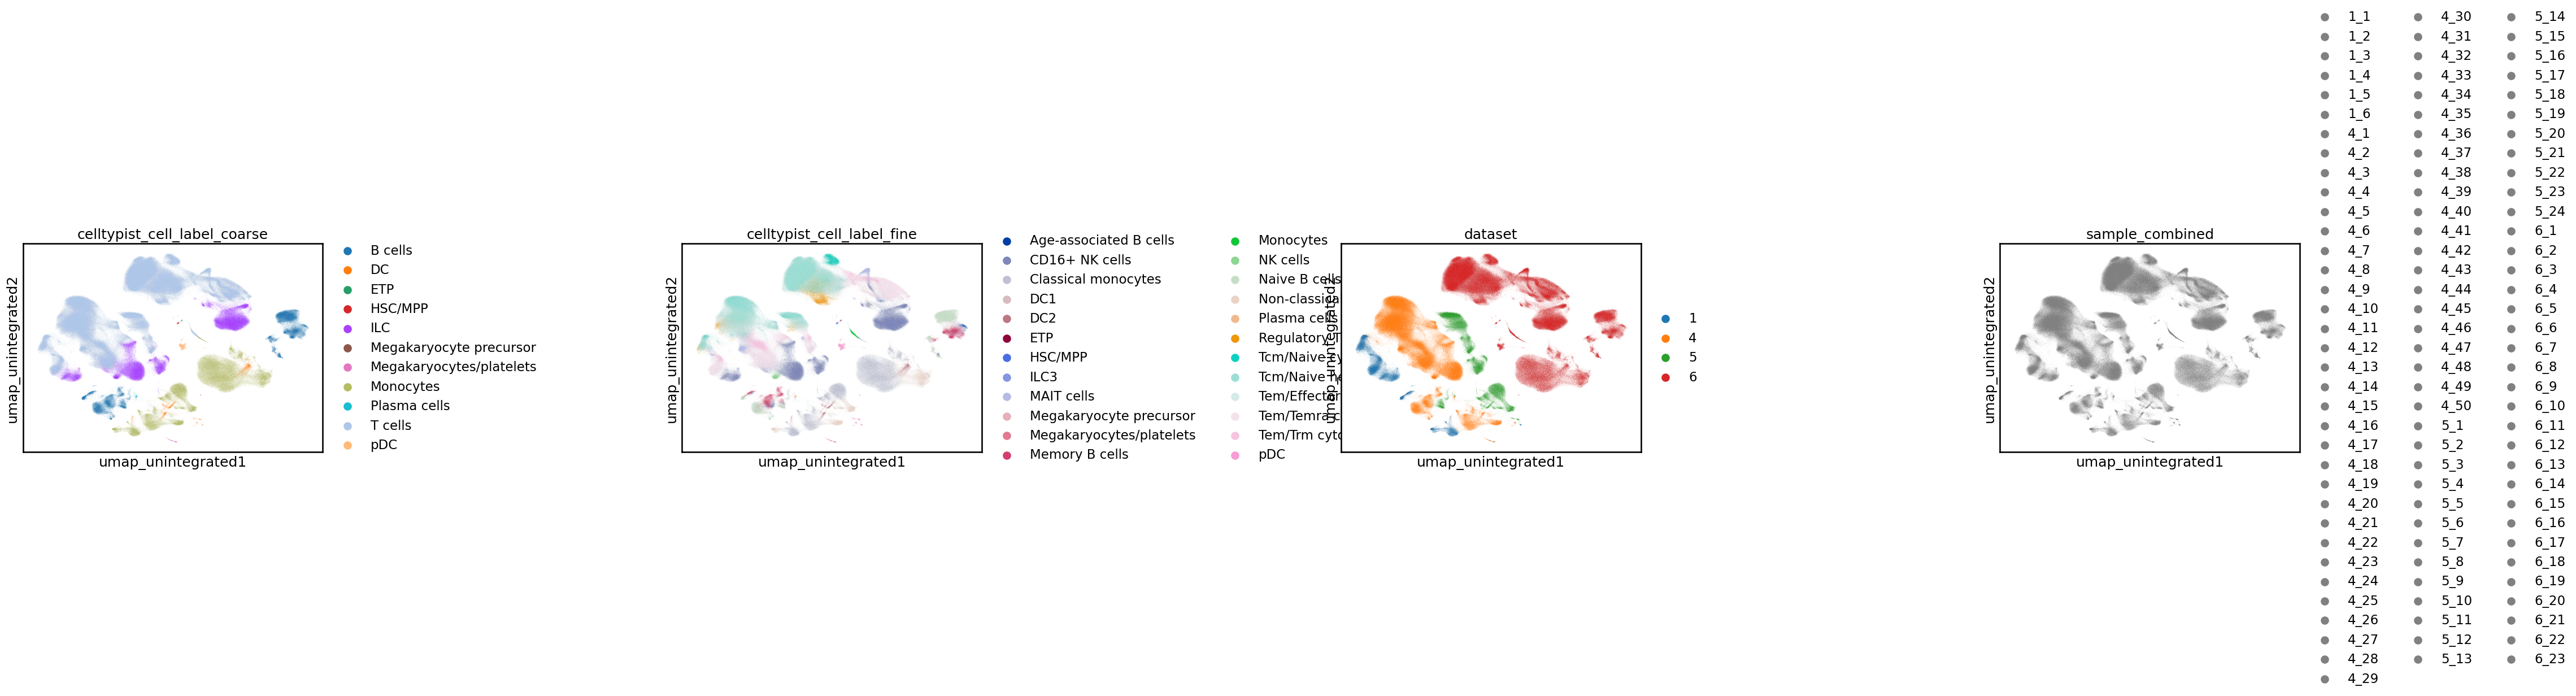

In [18]:
# plot the UMAP (pre integration) coloured by cell type and batch

sc.pl.embedding(adata, basis = "umap_unintegrated", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [19]:
# check on HVG selection

adata.var

,feature_types,mt,gene_symbols,genome,gene_versions,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
NOC2L,Gene Expression,False,NOC2L,cellranger_reference,ENSG00000188976,False,NaN,0.285631,0.351974,0.911106,0
KLHL17,Gene Expression,False,KLHL17,cellranger_reference,ENSG00000187961,False,NaN,0.050728,0.063351,0.936860,0
PLEKHN1,Gene Expression,False,PLEKHN1,cellranger_reference,ENSG00000187583,False,NaN,0.015196,0.022487,0.964644,0
HES4,Gene Expression,False,HES4,cellranger_reference,ENSG00000188290,True,467.5,0.048611,0.142334,1.725417,4
ISG15,Gene Expression,False,ISG15,cellranger_reference,ENSG00000187608,True,223.0,0.485958,2.173630,2.037325,3
...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,Gene Expression,True,MT-ND4L,cellranger_reference,ENSG00000212907,False,NaN,3.314371,16.182858,0.829951,0
MT-ND4,Gene Expression,True,MT-ND4,cellranger_reference,ENSG00000198886,False,NaN,5.994348,34.813211,0.670305,0
MT-ND5,Gene Expression,True,MT-ND5,cellranger_reference,ENSG00000198786,True,994.0,2.823992,9.452907,0.854809,1
MT-ND6,Gene Expression,True,MT-ND6,cellranger_reference,ENSG00000198695,True,416.5,2.238105,7.884516,1.219480,2


highly_variable_nbatches
0    8729
1    1644
2    1267
4     609
3     462
Name: count, dtype: int64

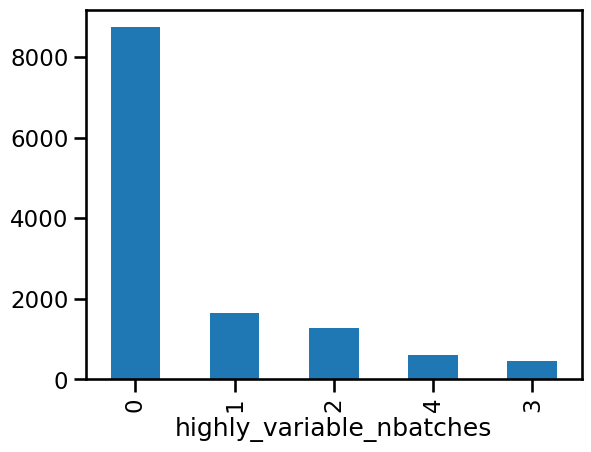

In [20]:
# check how many batches each gene is variable in

n_batches = adata.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

# this is the total number of genes that are highly variable, of which 2000 are selected (all the ones in 2 and rest from 1)

In [21]:
#### Method 1: Harmony

ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "dataset") # variable made so it doesn't write to adata.obsm("X_pca")
adata.obsm["X_pca_harmony"] = ho.Z_corr 

print(adata.obsm["X_pca_harmony"].shape)


2026-05-13 08:10:43,932 - harmonypy - INFO - Running Harmony (PyTorch on cuda)


2026-05-13 08:10:43,932 - harmonypy - INFO -   Parameters:


2026-05-13 08:10:43,932 - harmonypy - INFO -     max_iter_harmony: 10


2026-05-13 08:10:43,932 - harmonypy - INFO -     max_iter_kmeans: 20


2026-05-13 08:10:43,933 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-05-13 08:11:20,698 - harmonypy - INFO - Iteration 5 of 10


2026-05-13 08:11:21,332 - harmonypy - INFO - Iteration 6 of 10


2026-05-13 08:11:21,933 - harmonypy - INFO - Iteration 7 of 10


2026-05-13 08:11:22,501 - harmonypy - INFO - Converged after 7 iterations


(880872, 50)


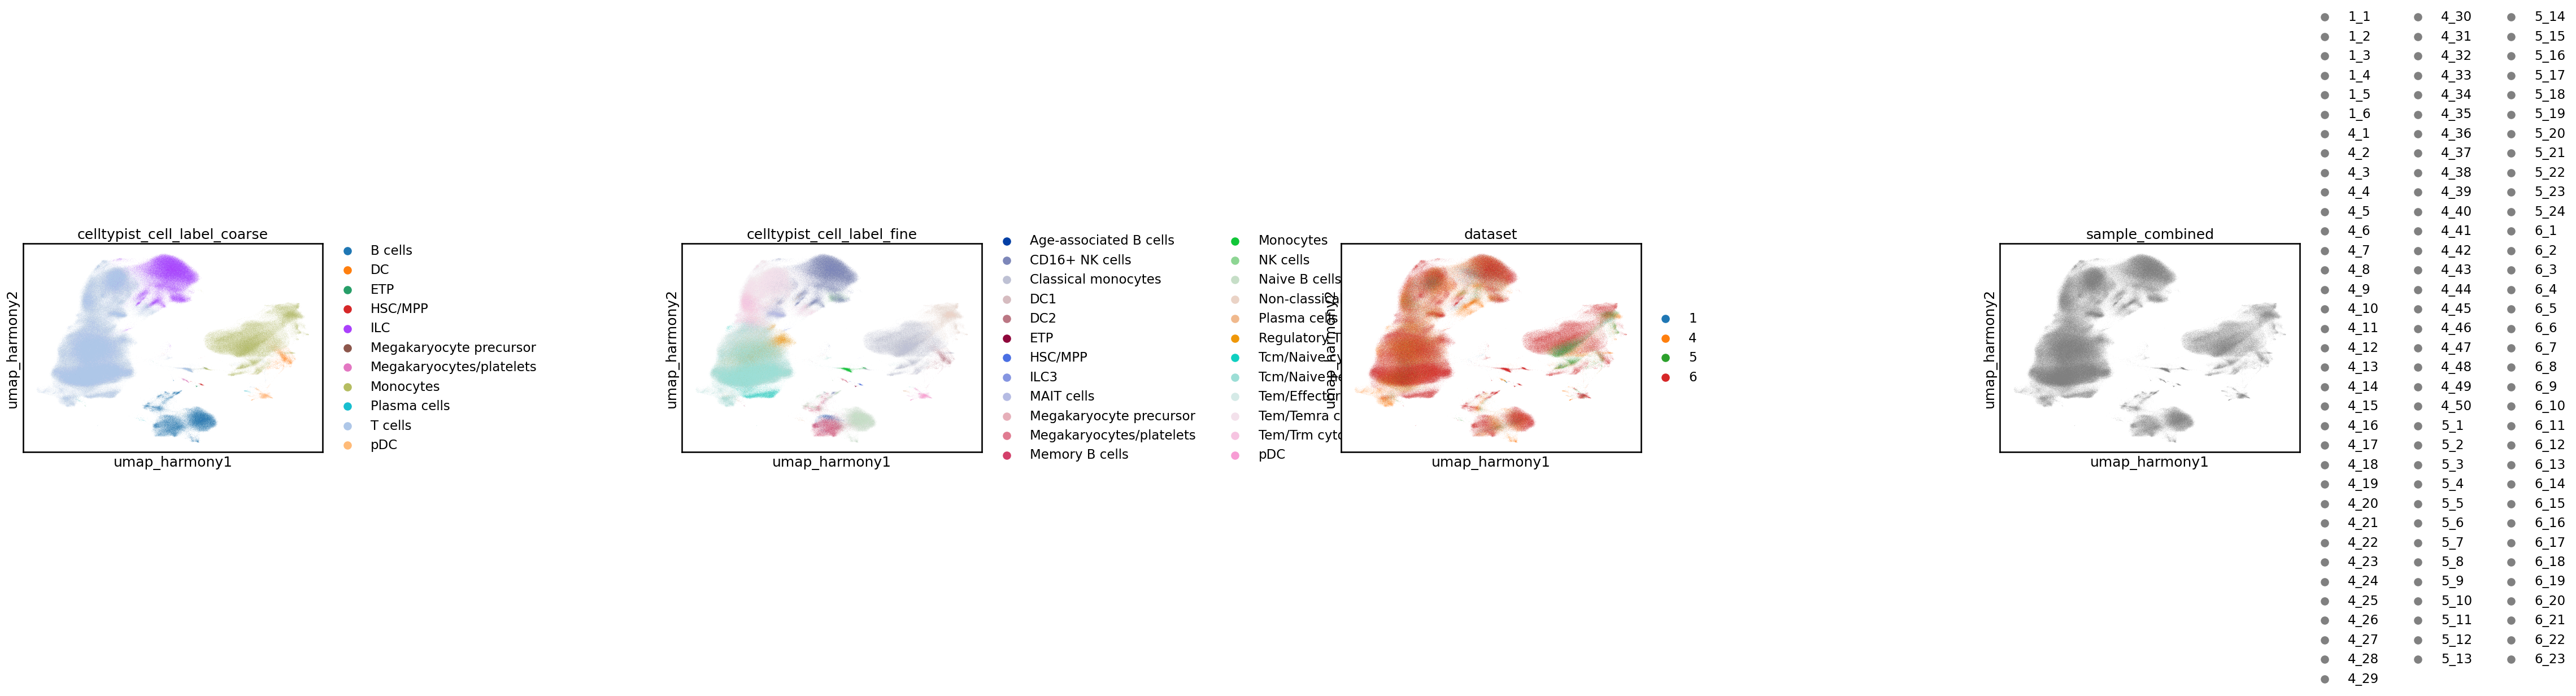

In [22]:
# recompute UMAP and neighbours using corrected data

sc.pp.neighbors(adata, use_rep="X_pca_harmony", key_added = "harmony")

sc.tl.umap(adata, neighbors_key="harmony") # swrites to X_umap
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()

# plot to check for overcorrection
sc.pl.embedding(adata, basis = "umap_harmony", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [23]:
#### Method 2: BBKNN

# heuristic for number of neighbours per graph
neighbors_within_batch = 25 if adata.n_obs > 100000 else 3
neighbors_within_batch

adata.X = adata.layers["log1p_norm"] #make sure we're working with log data (should already be adata.X, but just to be sure) 

In [24]:
# save unintegrated neighbors (bbknn doesntl allow for specifying a key, so default will be overwritten)

adata.uns["neighbors_unintegrated"] = adata.uns["neighbors"].copy()
adata.obsp["distances_unintegrated"] = adata.obsp["distances"].copy()
adata.obsp["connectivities_unintegrated"] = adata.obsp["connectivities"].copy()

In [25]:
bbknn.bbknn(
    adata, batch_key="dataset", neighbors_within_batch=neighbors_within_batch
)
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'sample_combined_colors', 'harmony', 'neighbors_unintegrated'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated', 'X_pca_harmony', 'X_umap_harmony'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'distances', 'connectivities', 'harmony_distances'

In [26]:
# save bbknn outputs under named keys 
adata.uns["bbknn"]                = adata.uns["neighbors"].copy()
adata.obsp["distances_bbknn"]     = adata.obsp["distances"].copy()
adata.obsp["connectivities_bbknn"] = adata.obsp["connectivities"].copy()

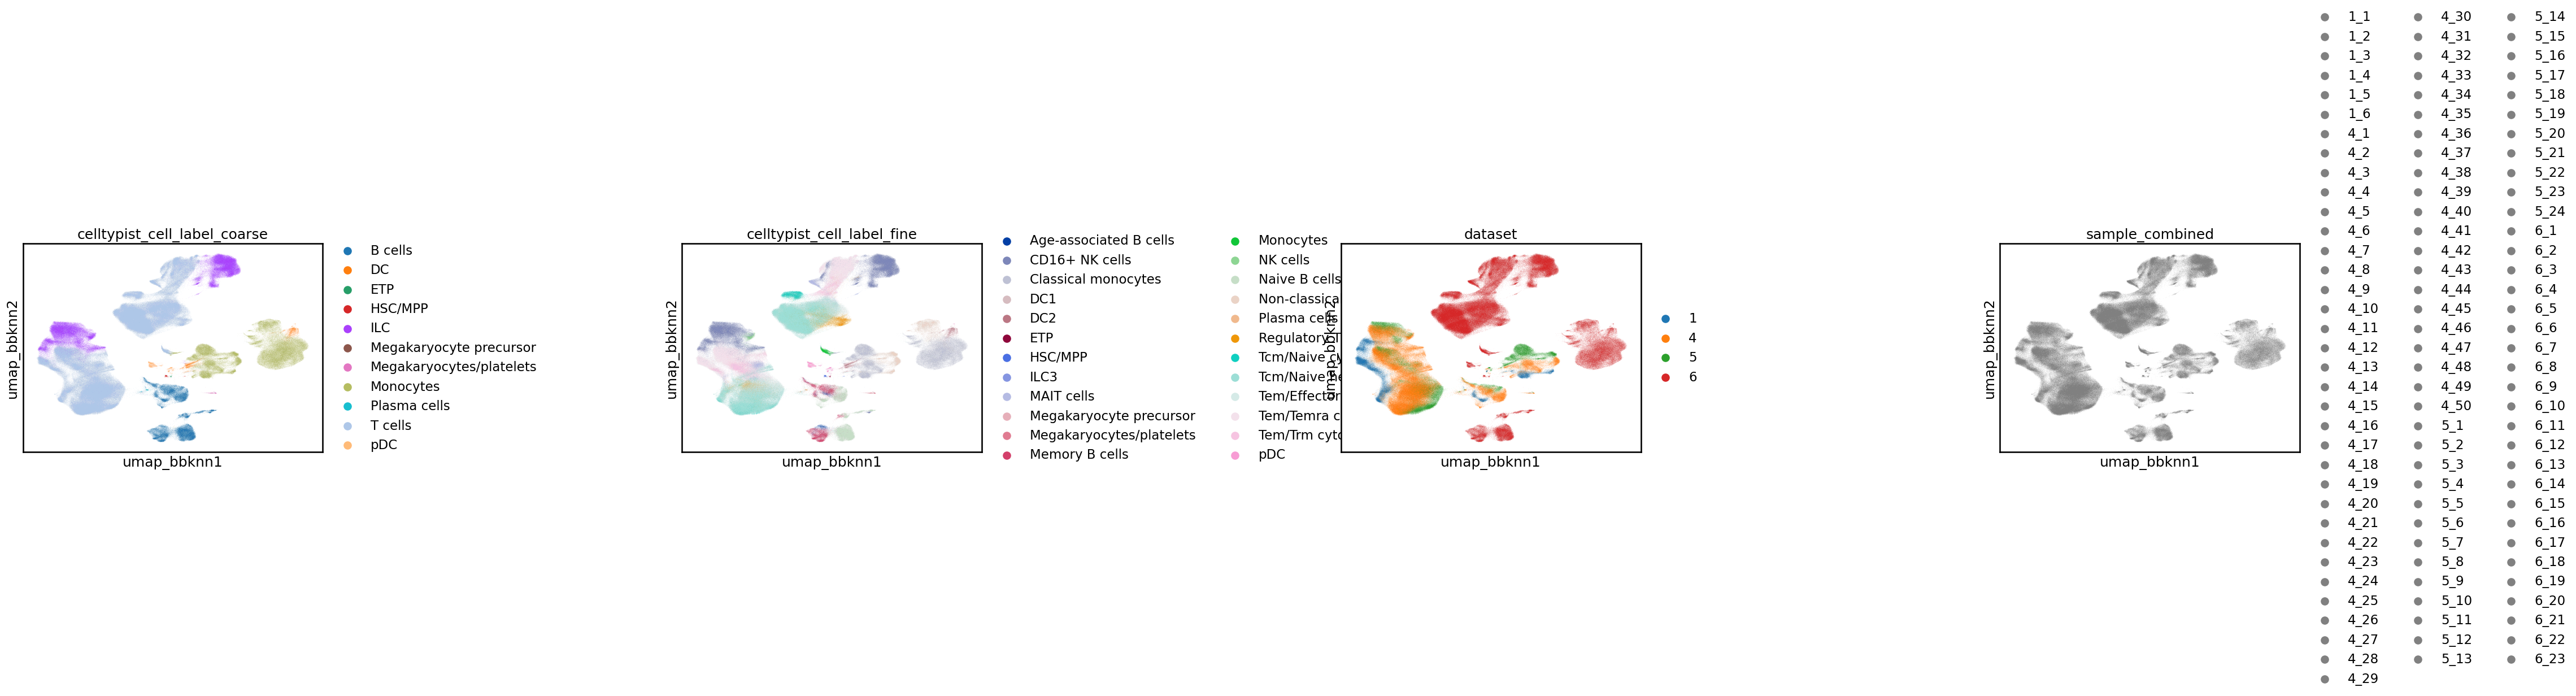

In [27]:
sc.tl.umap(adata) #writes to X_umap
adata.obsm["X_umap_bbknn"] = adata.obsm["X_umap"].copy()
sc.pl.embedding(adata, basis = "umap_bbknn", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [28]:
#### Method 3: Scanorama
import scanpy.external as sce
import scanorama

# set log1p_norm layer as adata.X for scanorama (since it doesn't allow for specifying a layer)
adata.X = adata.layers["log1p_norm"]

sce.pp.scanorama_integrate(adata, key="dataset")


[[0.00000000e+00 4.42828866e-01 7.58458664e-03 3.69979836e-05]
 [0.00000000e+00 0.00000000e+00 5.38680968e-01 2.69834823e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 5.81545717e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]
Processing datasets 4 <=> 5


Processing datasets 1 <=> 4


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


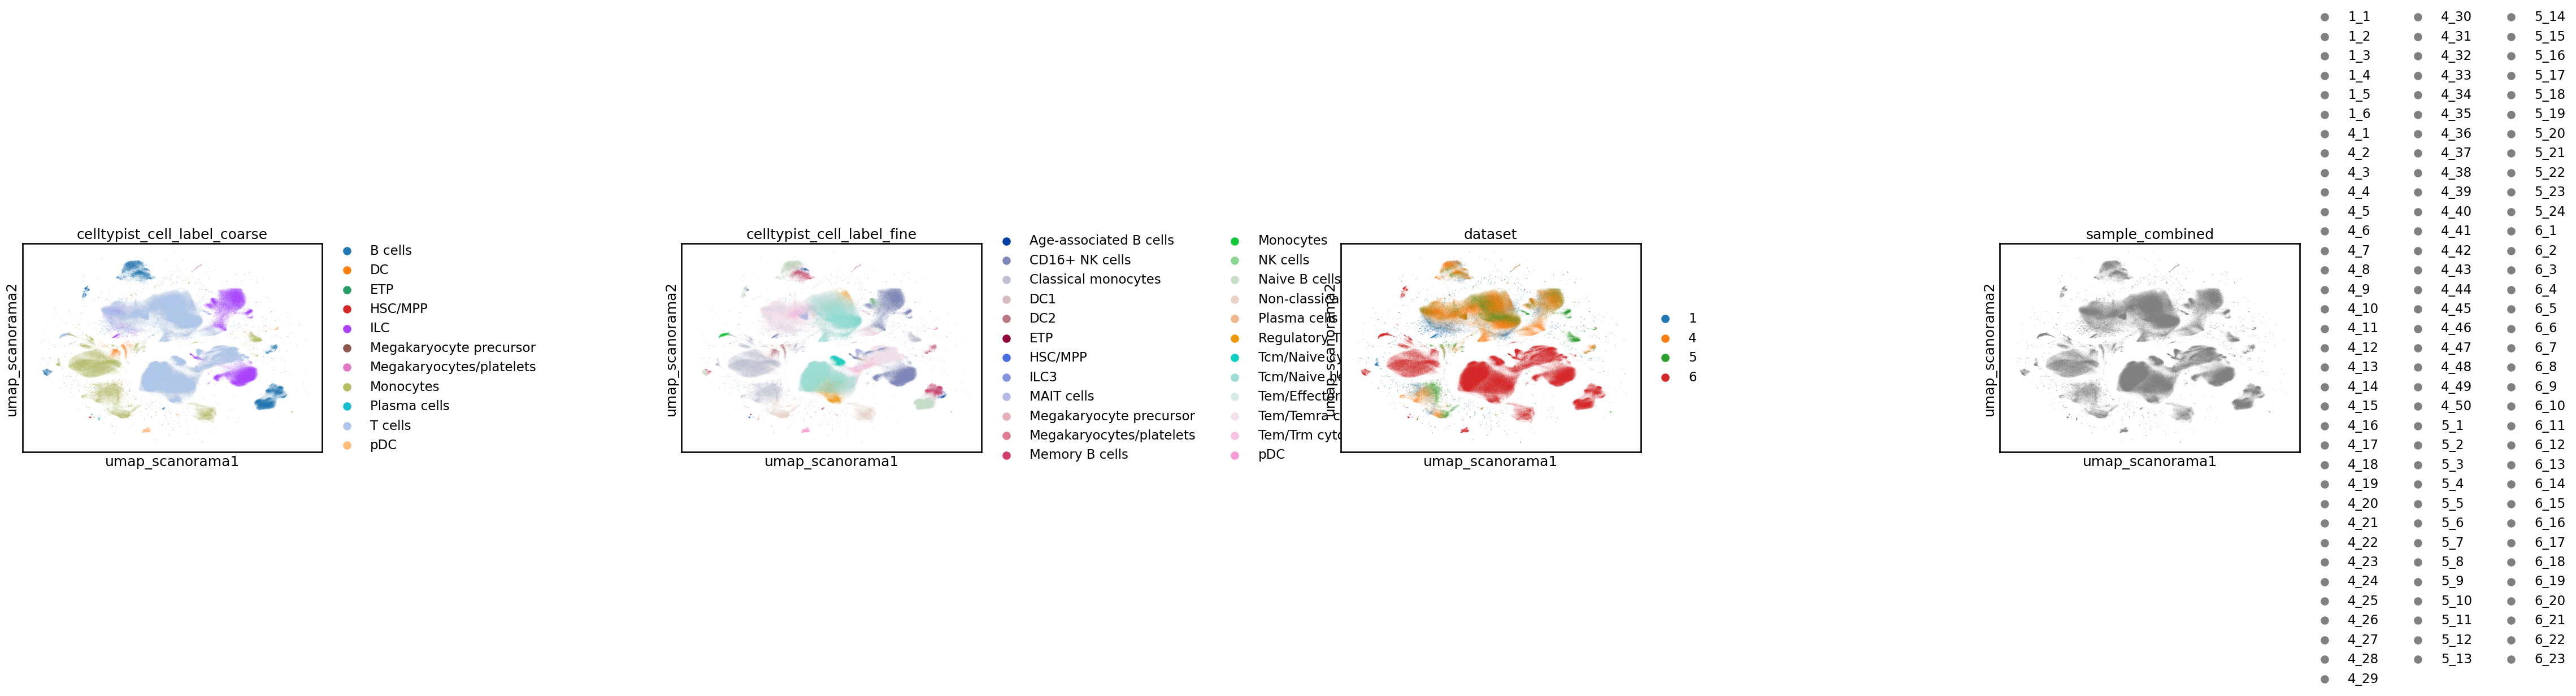

In [29]:
# recompute UMAP and neighbours using corrected data

sc.pp.neighbors(adata, use_rep="X_scanorama", key_added = "scanorama")

sc.tl.umap(adata, neighbors_key="scanorama") #writes to X_umap
adata.obsm["X_umap_scanorama"] = adata.obsm["X_umap"].copy()

# plot to check for overcorrection
sc.pl.embedding(adata, basis = "umap_scanorama", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [30]:
#### Method : scVI

# create object with just selected genes to use for integration (scVI and scANVI dont work in PCA space, so need subsetted object)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg


AnnData object with n_obs × n_vars = 880872 × 2000
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'sample_combined_colors', 'harmony', 'neighbors_unintegrated', 'bbknn', 'scanorama'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated', 'X_pca_harmony', 'X_umap_harmony', 'X_umap_bbknn', 'X_scanorama', 'X_umap_scanorama'
    varm: 'PCs'
    layers: 'counts', '

In [31]:
adata_scvi = adata_hvg.copy()
# try without HVG

In [32]:
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key="dataset")
adata_scvi

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


AnnData object with n_obs × n_vars = 880872 × 2000
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'sample_combined_colors', 'harmony', 'neighbors_unintegrated', 'bbknn', 'scanorama', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated', 'X_pca_harmony', 'X_umap_harmony', 'X_umap_bbknn', 'X_sca

In [33]:
model_scvi = scvi.model.SCVI(adata_scvi)
model_scvi

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [34]:
# model_scvi.view_anndata_setup()
# come back and fix dependency issue, not necessary for now as this is just to view

In [35]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])
print(max_epochs_scvi)

9


In [36]:
model_scvi.train()

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-c2cff6e2-81a7-4fa3-761b-bfd57f1efa94]


...

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)



Epoch 9/9: 100%|██████████| 9/9 [07:32<00:00, 49.93s/it, v_num=1, train_loss=734]


Epoch 9/9: 100%|██████████| 9/9 [07:32<00:00, 49.93s/it, v_num=1, train_loss=734]

`Trainer.fit` stopped: `max_epochs=9` reached.



Epoch 9/9: 100%|██████████| 9/9 [07:32<00:00, 50.28s/it, v_num=1, train_loss=734]

In [37]:
# extract trained embedding (similar to how PCA dimensions are used)
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()

# copy back into original adata
adata.obsm["X_scVI"] = adata_scvi.obsm["X_scVI"].copy() 

In [38]:
# compute scVI batch-corrected neighbors and UMAP
sc.pp.neighbors(adata_scvi, use_rep="X_scVI", key_added = "scVI")

sc.tl.umap(adata_scvi, neighbors_key="scVI")
adata.obsm["X_umap_scVI"] = adata_scvi.obsm["X_umap"].copy() #if HVG also needed for other methods, rename adata_scvi to just adata_hvg

adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'sample_combined_colors', 'harmony', 'neighbors_unintegrated', 'bbknn', 'scanorama'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated', 'X_pca_harmony', 'X_umap_harmony', 'X_umap_bbknn', 'X_scanorama', 'X_umap_scanorama', 'X_scVI', 'X_umap_scVI'
    varm: 'PC

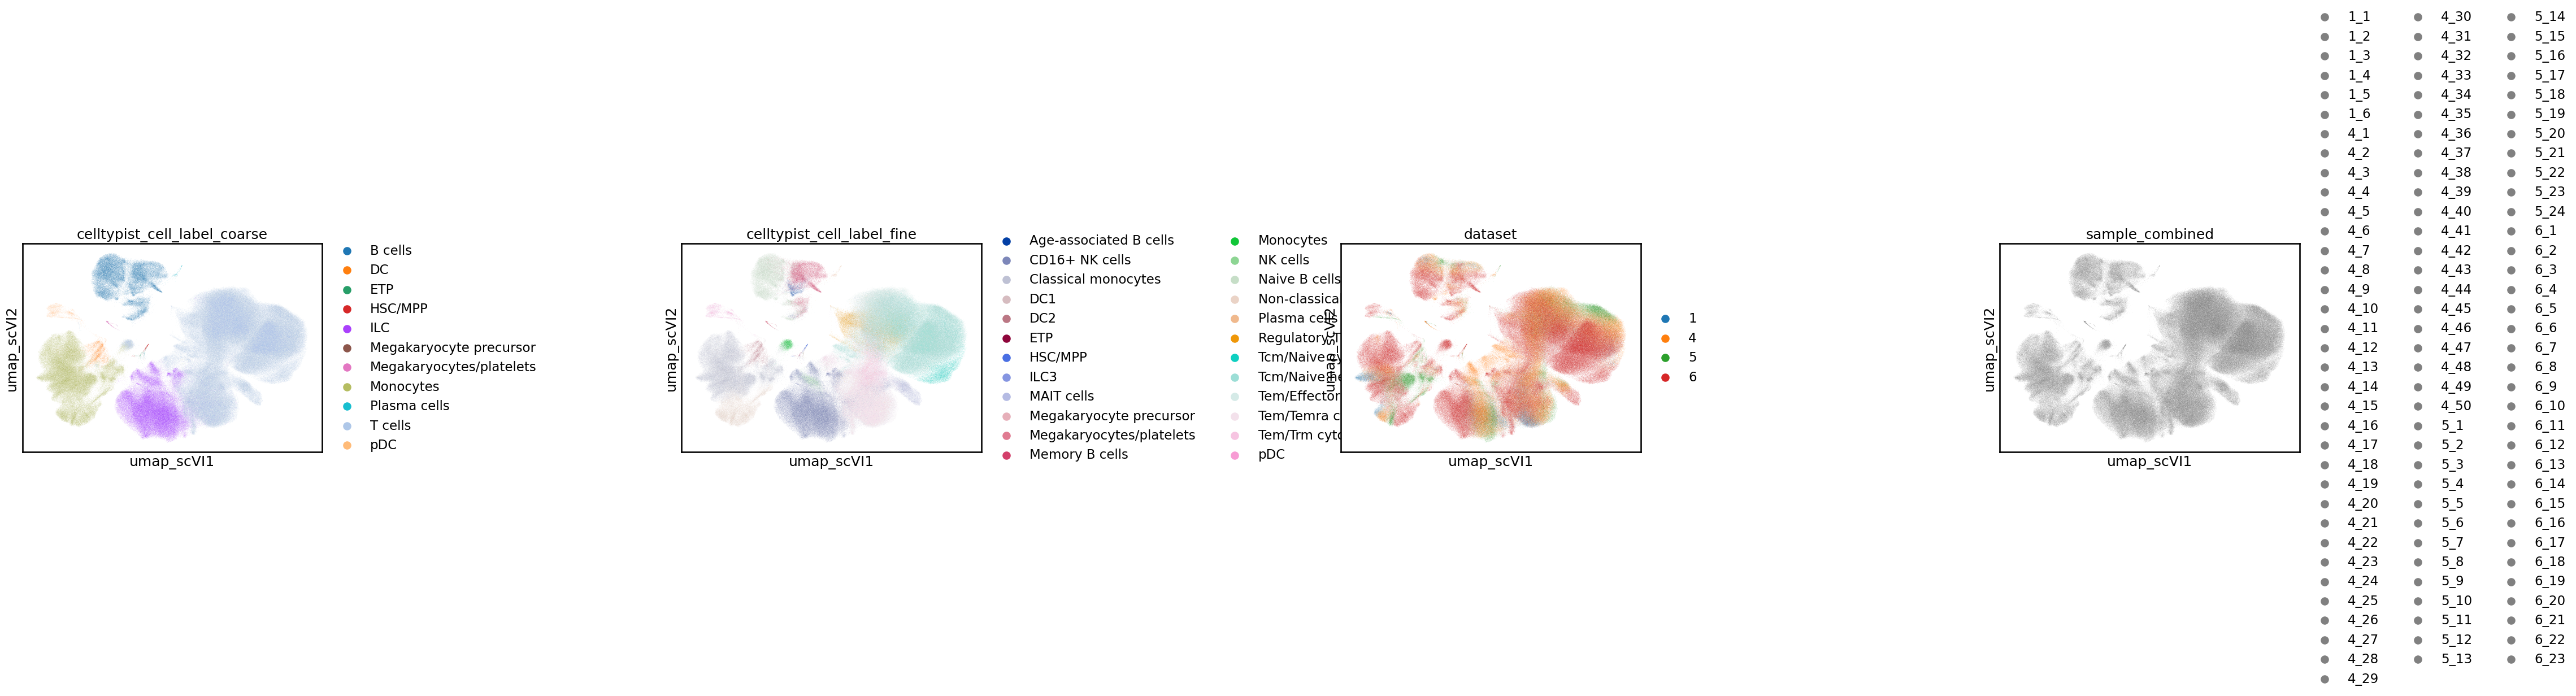

In [39]:
# plot UMAP
sc.pl.embedding(adata, basis="umap_scVI", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [40]:
#### Method 5: scANVI

# create scanvi object using trained scvi model, specifying cell type labels and dummy for unlabelled (since all cells are labelled)
model_scanvi = scvi.model.SCANVI.from_scvi_model(
    model_scvi, labels_key="celltypist_cell_label_fine", unlabeled_category="unlabelled" # can also do with broad and compare, but fine should be more challenging so good to test on that
)
print(model_scanvi)


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


ScanVI Model with the following params: 
unlabeled_category: unlabelled, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Not Trained
Model's adata is minified?: False

In [41]:
# heuristic for deciding number of epochs for scANVI training

max_epochs_scanvi = int(np.min([10, np.max([2, round(max_epochs_scvi / 3.0)])]))
model_scanvi.train(max_epochs=max_epochs_scanvi)

INFO     Training for 3 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [GPU-c2cff6e2-81a7-4fa3-761b-bfd57f1efa94]


...

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)



Epoch 3/3: 100%|██████████| 3/3 [05:09<00:00, 103.10s/it, v_num=1, train_loss=744]


Epoch 3/3: 100%|██████████| 3/3 [05:09<00:00, 103.10s/it, v_num=1, train_loss=743]

`Trainer.fit` stopped: `max_epochs=3` reached.



Epoch 3/3: 100%|██████████| 3/3 [05:09<00:00, 103.18s/it, v_num=1, train_loss=743]

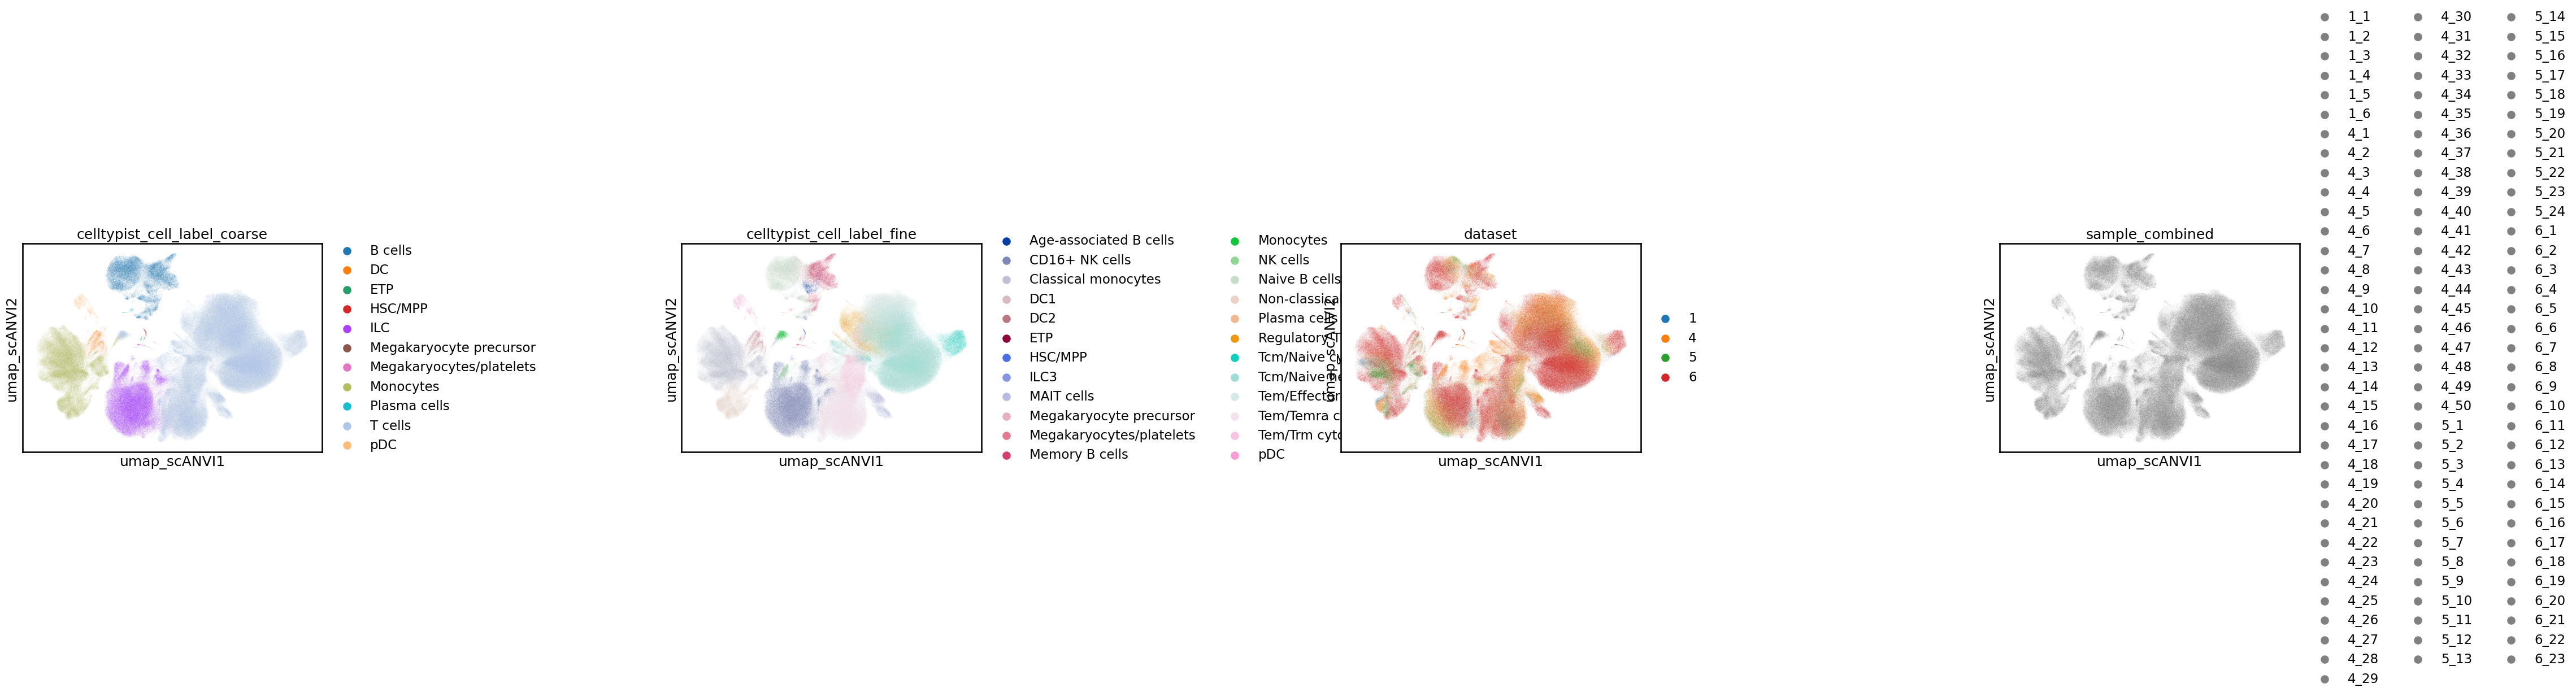

In [ ]:
adata.obsm["X_scANVI"] = model_scanvi.get_latent_representation() # write back to original adata
sc.pp.neighbors(adata, use_rep="X_scANVI", key_added="scANVI")
sc.tl.umap(adata, neighbors_key="scANVI")
adata.obsm["X_umap_scANVI"] = adata.obsm["X_umap"].copy()
sc.pl.embedding(adata, basis="umap_scANVI", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [43]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'sample_combined_colors', 'harmony', 'neighbors_unintegrated', 'bbknn', 'scanorama', 'scANVI'
    obsm: 'X_pca', 'X_umap', 'X_umap_unintegrated', 'X_pca_harmony', 'X_umap_harmony', 'X_umap_bbknn', 'X_scanorama', 'X_umap_scanorama', 'X_scVI', 'X_umap_scVI', 'X

In [44]:
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata.h5ad")